In [1]:
%pip install tensorflow>=2.15.0 streamlit "protobuf>=4.21.0,<6"

Note: you may need to restart the kernel to use updated packages.


In [1]:

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: []


In [2]:
# Paths & Hyperparameters
TRAINING_PATH   = 'D:/FINAL YEAR_PROJECT/Disease_Classification/Plants_dataSet/Apple/Train'
VALIDATION_PATH = 'D:/FINAL YEAR_PROJECT/Disease_Classification/Plants_dataSet/Apple/Validation'

BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)
EPOCHS_HEAD  = 15   # phase 1: train new head only
EPOCHS_FINE  = 20   # phase 2: fine-tune top layers
UNFREEZE_N   = 50   # how many base layers to unfreeze from the end
LR_HEAD      = 1e-3
LR_FINE      = 1e-5

In [3]:
## 2. Data Augmentation (KEY accuracy booster)
# Applied on-the-fly during training only
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
], name='augmentation')

In [4]:
## 3. Load & Build Pipeline
training_set = tf.keras.utils.image_dataset_from_directory(
    TRAINING_PATH, label_mode='categorical',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
validation_set = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_PATH, label_mode='categorical',
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = training_set.class_names
NUM_CLASSES = len(class_names)
print(f'Classes ({NUM_CLASSES}):', class_names)

# Save for web app
#with open('class_names.json', 'w') as f:
#    json.dump(class_names, f)
#print('class_names.json saved')

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    training_set
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE)
)

val_ds = (
    validation_set
    .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE)
)

Found 2536 files belonging to 4 classes.
Found 635 files belonging to 4 classes.
Classes (4): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']


In [5]:
## 4. Build Model (improved head with BatchNorm)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,625,476 (10.02 MB)

 Trainable params: 364,420 (1.39 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [6]:
## 5. Phase 1 — Train head only
model.compile(
    optimizer=Adam(LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_head = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ModelCheckpoint('best_model_head.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS_HEAD, callbacks=callbacks_head)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 88s 1000ms/step - accuracy: 0.8545 - loss: 0.4187 - top3_acc: 0.9826 - val_accuracy: 0.9055 - val_loss: 0.2461 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 71s 896ms/step - accuracy: 0.9578 - loss: 0.1213 - top3_acc: 1.0000 - val_accuracy: 0.9402 - val_loss: 0.1737 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 70s 873ms/step - accuracy: 0.9704 - loss: 0.0835 - top3_acc: 0.9996 - val_accuracy: 0.9354 - val_loss: 0.1708 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 77s 965ms/step - accuracy: 0.9842 - loss: 0.0457 - top3_acc: 0.9996 - val_accuracy: 0.9512 - val_loss: 0.1510 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 72s 906ms/step - accuracy: 0.9886 - loss: 0.0351 - top3_acc: 1.0000 - val_accuracy: 0.9685 - val_loss: 0.1265 - val_top3_acc: 1.0000 - learning_rate: 0.0010
Epoch 6/15
80/80 ━━━━━━━

In [7]:
## 6. Phase 2 — Fine-tune top base layers
base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_N]:
    layer.trainable = False

print(f'Fine-tuning {sum(1 for l in base_model.layers if l.trainable)} base layers')

model.compile(
    optimizer=Adam(LR_FINE),  # must be very low!
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_fine = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy', verbose=1),
    ModelCheckpoint('best_model_final.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.3, patience=4, min_lr=1e-8, verbose=1)
]

history_fine = model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS_FINE, callbacks=callbacks_fine)

Fine-tuning 50 base layers
Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.9058 - loss: 0.2780 - top3_acc: 0.9976 - val_accuracy: 0.9622 - val_loss: 0.1663 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9594 - loss: 0.1116 - top3_acc: 0.9984 - val_accuracy: 0.9591 - val_loss: 0.2010 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.9771 - loss: 0.0623 - top3_acc: 1.0000 - val_accuracy: 0.9591 - val_loss: 0.2110 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.9791 - loss: 0.0489 - top3_acc: 1.0000 - val_accuracy: 0.9575 - val_loss: 0.2179 - val_top3_acc: 1.0000 - learning_rate: 1.0000e-05
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9848 - loss: 0.0365 - top3_acc: 0.9995
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
80/80 

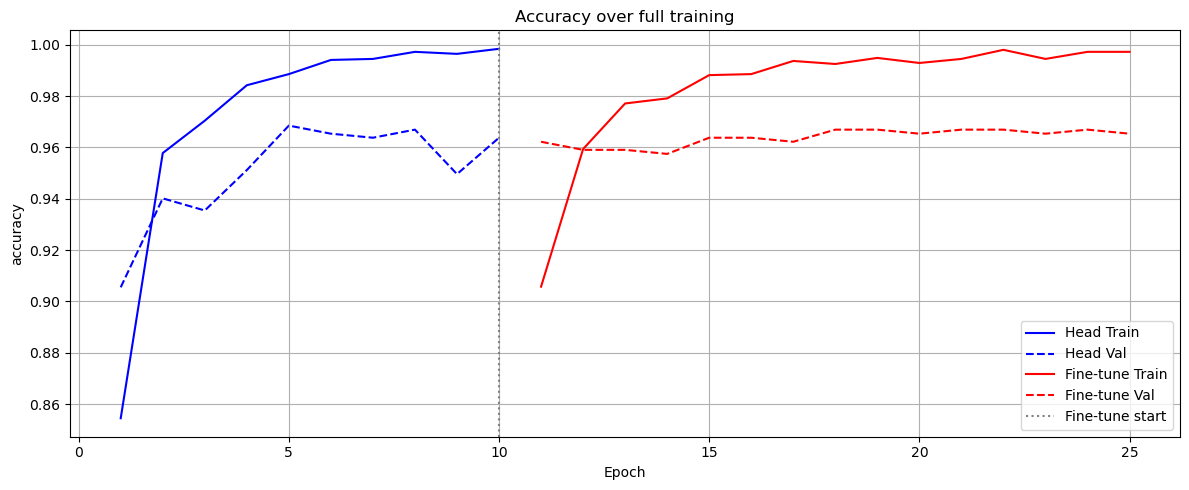

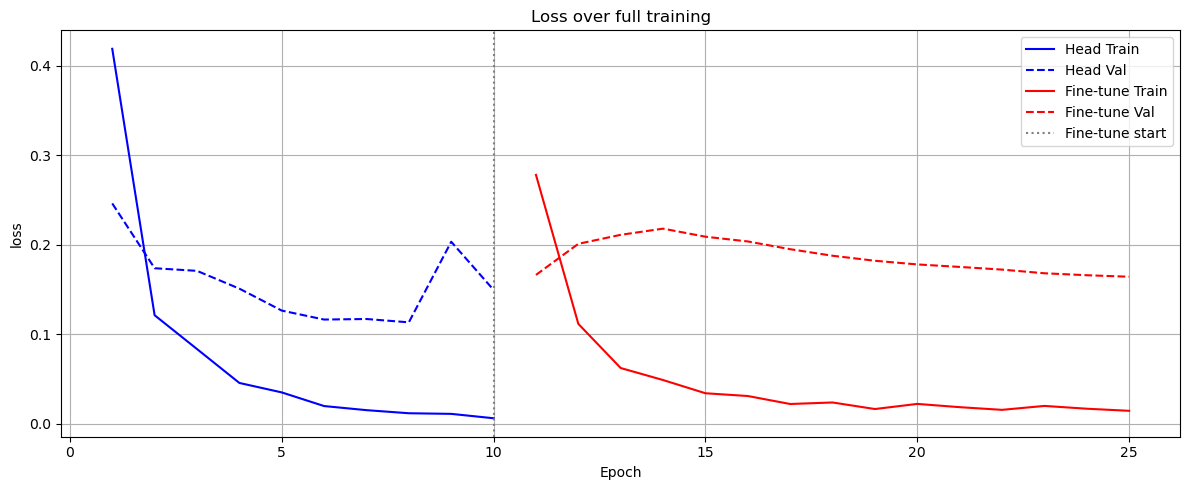

In [8]:
def plot_combined(h1, h2, metric='accuracy'):
    v1, val1 = h1.history[metric], h1.history[f'val_{metric}']
    v2, val2 = h2.history[metric], h2.history[f'val_{metric}']
    e1 = range(1, len(v1)+1)
    e2 = range(len(v1)+1, len(v1)+len(v2)+1)
    plt.figure(figsize=(12,5))
    plt.plot(list(e1), v1, 'b-',  label='Head Train')
    plt.plot(list(e1), val1, 'b--', label='Head Val')
    plt.plot(list(e2), v2, 'r-',  label='Fine-tune Train')
    plt.plot(list(e2), val2, 'r--', label='Fine-tune Val')
    plt.axvline(x=len(v1), color='gray', linestyle=':', label='Fine-tune start')
    plt.title(f'{metric.capitalize()} over full training')
    plt.xlabel('Epoch'); plt.ylabel(metric); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.savefig(f'training_{metric}.png', dpi=150); plt.show()

plot_combined(history, history_fine, 'accuracy')
plot_combined(history, history_fine, 'loss')

In [10]:
best = tf.keras.models.load_model('best_model_final.keras')
best.save('Apple_disease.keras')
print('Saved: Apple_disease.keras')

loss, acc, top3 = best.evaluate(val_ds)
print(f'\nVal Accuracy  : {acc*100:.2f}%')
print(f'Top-3 Accuracy: {top3*100:.2f}%')

Saved: Apple_disease.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 752ms/step - accuracy: 0.9669 - loss: 0.1877 - top3_acc: 1.0000

Val Accuracy  : 96.69%
Top-3 Accuracy: 100.00%
